In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data= pd.read_csv('CitasDigital_sin_nulos.csv') 

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 653 entries, 0 to 652
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                653 non-null    int64  
 1   BDC                                       653 non-null    str    
 2   Fecha                                     653 non-null    str    
 3   Nombre Cliente                            653 non-null    str    
 4   Estatus de Lead                           653 non-null    str    
 5   Potencial de compra                       653 non-null    float64
 6   PDM                                       653 non-null    float64
 7   SDC                                       653 non-null    float64
 8   Venta                                     653 non-null    float64
 9   Asesor Asignado                           653 non-null    str    
 10  ¿Por que no ha visitado la agencia?       653 non

In [4]:
valores_nulos=data.isnull().sum()
valores_nulos

Unnamed: 0                                  0
BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Estatus de Lead                             0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
Comentarios Adicionales                     0
dtype: int64

Identificar columnas cualitativas y cuantitativas

In [6]:
#Creamos 2 dataframes para poder procesar los outliers
columnas_cuantitativas = ['Potencial de compra', 'PDM', 'SDC', 'Venta']

cuantitativas = data[columnas_cuantitativas]
cualitativas = data.drop(columns=columnas_cuantitativas)

cuantitativas.head()

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,1.0
4,0.90,1.0,0.0,0.0


<Figure size 1500x800 with 0 Axes>

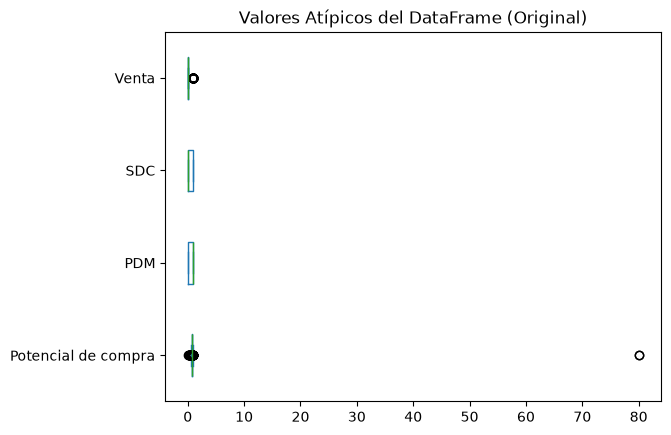

In [8]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize=(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del DataFrame (Original)")
plt.show()

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [9]:
#Método aplicando desviación estándar. Encuentro los valores extremos
y = cuantitativas
Limite_Superior = y.mean() + 3*y.std()
Limite_Inferior = y.mean() - 3*y.std()
print("Limite superior permitido:\n", Limite_Superior)
print("\nLimite inferior permitido:\n", Limite_Inferior)

Limite superior permitido:
 Potencial de compra    14.129413
PDM                     2.006423
SDC                     1.889632
Venta                   0.942930
dtype: float64

Limite inferior permitido:
 Potencial de compra   -12.181940
PDM                    -0.995704
SDC                    -1.065743
Venta                  -0.765288
dtype: float64


In [10]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data3= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
648,0.80,1.0,1.0,0.0
649,0.50,0.0,0.0,0.0
650,0.50,1.0,0.0,0.0
651,1.00,1.0,1.0,NaN


In [11]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data3.isnull().sum()
valores_nulos

Potencial de compra     2
PDM                     0
SDC                     0
Venta                  58
dtype: int64

In [12]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data3.copy()
data_clean=data_clean.fillna(round(data3.mean(),1))
data_clean

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
648,0.80,1.0,1.0,0.0
649,0.50,0.0,0.0,0.0
650,0.50,1.0,0.0,0.0
651,1.00,1.0,1.0,0.0


In [13]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

Potencial de compra    0
PDM                    0
SDC                    0
Venta                  0
dtype: int64

**PROCEDIMIENTO "CUANTILES" PARA SUSTITUIR OUTLIERS EN DATAFRAME**

In [14]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Potencial de compra    0.95
PDM                    2.50
SDC                    2.50
Venta                  0.00
dtype: float64
Limite inferior permitido Potencial de compra    0.55
PDM                   -1.50
SDC                   -1.50
Venta                  0.00
dtype: float64


In [15]:
#Obtenemos datos limpios del Dataframe
data3_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,NaN,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
648,0.80,1.0,1.0,0.0
649,NaN,0.0,0.0,0.0
650,NaN,1.0,0.0,0.0
651,NaN,1.0,1.0,NaN


In [16]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data3_iqr.isnull().sum()
valores_nulos

Potencial de compra    73
PDM                     0
SDC                     0
Venta                  58
dtype: int64

In [17]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data4_iqr=data3_iqr.copy()
data4_iqr=data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.80,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
648,0.80,1.0,1.0,0.0
649,0.80,0.0,0.0,0.0
650,0.80,1.0,0.0,0.0
651,0.80,1.0,1.0,0.0


In [18]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data4_iqr], axis=1)
Datos_limpios

,Unnamed: 0,BDC,Fecha,Nombre Cliente,Estatus de Lead,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Comentarios Adicionales,Potencial de compra,PDM,SDC,Venta
0,0,Saul,Abril 2025,Guillermo,Finalizado,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...,0.90,1.0,0.0,0.0
1,1,Saul,Abril 2025,Roberto,Finalizado,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,Sin comentario adicional,0.80,0.0,0.0,0.0
2,2,Saul,Abril 2025,Irving,Finalizado,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025,0.85,0.0,0.0,0.0
3,3,Saul,Abril 2025,Oswaldo,Venta,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",Sin comentario adicional,0.90,0.0,0.0,0.0
4,4,Saul,Abril 2025,Rodrigo,Finalizado,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...,0.90,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
648,671,Ana,2026-07-22,Maira Escalante,Activo,Pedro Antonio,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,1.0,1.0,0.0
649,672,Ignacio,2026-07-22,Zaira Macip,Activo,Aurelio,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,0.0,0.0,0.0
650,673,Ignacio,2026-07-27,Julio Hernandez,Activo,Victor,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,1.0,0.0,0.0
651,674,Ignacio,2026-07-24,Xhunaxhi Vicente,Activo,Ignacio,No aplica,No aplica,No aplica,No aplica,No aplica,Sin comentario adicional,0.80,1.0,1.0,0.0


In [19]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Unnamed: 0                                  0
BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Estatus de Lead                             0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
Comentarios Adicionales                     0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
dtype: int64

In [21]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("CitasDigital_sin_outliers.csv")

Dado el contexto del caso no veo necesario realizar la eliminación de los valores atípicos, pues la base de datos contiene 1 y 0 (que en la mayoria de los casos es si y no), y en el caso de las ventas específicamente, si veo factible (incluso beneficioso que se realicen más ventas de las usuales), hago el comentario como parte de mi análisis, pero entiendo que es importante hacer el ejercicio y nos aporta mucho el aprender a como trabajar con los valores atípicos.